# Vegemite Production — End-to-End Training Notebook (v3)

**Theme 3: Product Manufacturing / Mechanical Engineering**

**Improvements over v2 (XGBoost):**
1. **LightGBM** replaces XGBoost — faster training, better generalization on tabular data
2. **Lag features** (t-1, t-2) in addition to rolling mean — captures temporal dynamics
3. **Target encoding** for Part (yeast type) — encodes relationship with quality
4. **Threshold tuning** — grid search for optimal `low_bad` detection threshold
5. **Per-Part thresholds** — each yeast type gets its own optimized threshold
6. **Ordinal-aware evaluation** — treats quality as ordered (good > low_bad > high_bad)
7. **Comprehensive visualizations** — confusion matrices, feature importance, threshold curves

**Data:** good.csv, low bad.csv, high bad.csv; Downtime CSV.  
**Models:** LightGBM (quality multiclass + downtime binary). **Split:** time-aware 70/15/15.

---
## 1. Setup and Configuration

Install dependencies and configure paths for Kaggle or local environment.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)

# Install dependencies if needed
try:
    import lightgbm as lgb
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import SMOTE

import joblib

# === Paths ===
KAGGLE_ROOT = '/kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset'
if not os.path.exists(KAGGLE_ROOT):
    KAGGLE_ROOT = os.path.join(os.path.dirname(os.path.abspath('.')), 'Theme3', 'Theme3')
THEME3 = os.path.join(KAGGLE_ROOT, 'Theme3')
DATA_MAIN = os.path.join(THEME3, 'data_02_07_2019-26-06-2020')
DATA_DOWNTIME = os.path.join(THEME3, 'Downtime')
OUTPUT_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else '.'

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f'Data dir: {DATA_MAIN}')
print(f'Output dir: {OUTPUT_DIR}')
print(f'LightGBM version: {lgb.__version__}')

Data dir: /kaggle/input/datasets/nguyenletruongthien/vegemite-production-dataset/Theme3/data_02_07_2019-26-06-2020
Output dir: /kaggle/working
LightGBM version: 4.6.0


---
## 2. Load & Label Data

Load the three quality CSVs (good, low bad, high bad) and the downtime CSV.
Each quality file gets a label column.

In [2]:
def _find_file(folder, names):
    for n in names:
        p = os.path.join(folder, n)
        if os.path.isfile(p):
            return p
    return None

def load_production_and_downtime():
    dfs = []
    for label, names in [
        ('good', ['good.csv']),
        ('low_bad', ['low bad.csv', 'low_bad.csv']),
        ('high_bad', ['high bad.csv', 'high_bad.csv']),
    ]:
        path = _find_file(DATA_MAIN, names)
        if path is None:
            raise FileNotFoundError(f'Not found: {names} in {DATA_MAIN}')
        df = pd.read_csv(path)
        df['quality'] = label
        dfs.append(df)
    prod = pd.concat(dfs, ignore_index=True)

    downtime = None
    dt_path = _find_file(DATA_DOWNTIME, ['Yeast Prep DT 04_05_20 - 01_07_20.csv'])
    if dt_path:
        downtime = pd.read_csv(dt_path)
        date_col = [c for c in downtime.columns if 'date' in c.lower()]
        if date_col:
            downtime['date'] = pd.to_datetime(downtime[date_col[0]], dayfirst=True).dt.normalize()
    return prod, downtime

prod, downtime = load_production_and_downtime()
print(f'Total production rows: {len(prod)}')
print(f'\nQuality distribution:')
print(prod['quality'].value_counts())
print(f'\nParts: {prod["Part"].unique()}')
if downtime is not None:
    print(f'\nDowntime rows: {len(downtime)}')

Total production rows: 30375

Quality distribution:
quality
high_bad    14495
good        13302
low_bad      2578
Name: count, dtype: int64

Parts: ['Yeast - BRN' 'Yeast - BRD' 'Yeast - FMX']

Downtime rows: 218


---
## 3. Exploratory Data Analysis

Visualize the class distribution and quality breakdown by yeast type.

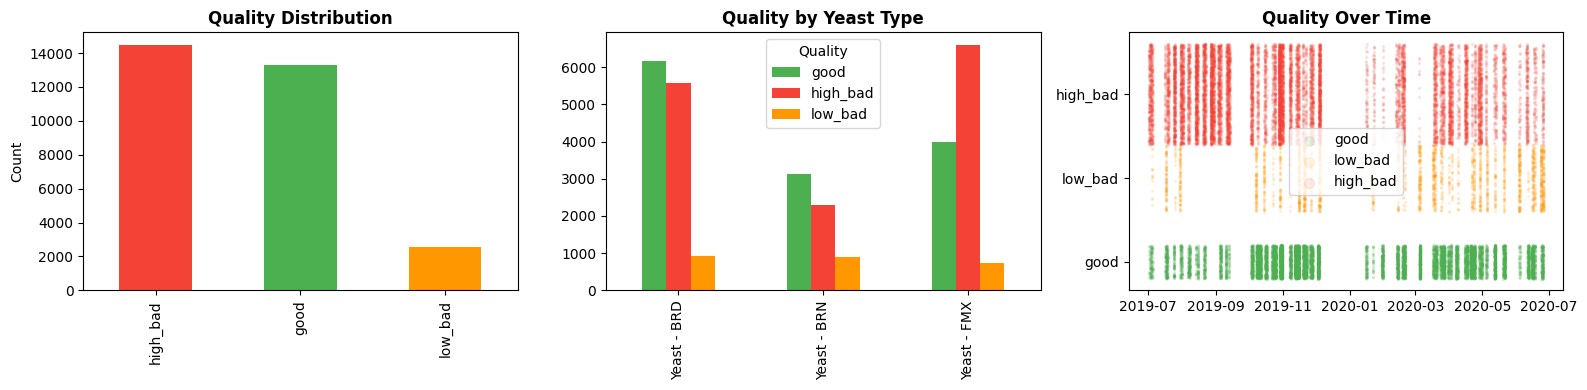

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Quality distribution
colors = {'good': '#4CAF50', 'low_bad': '#FF9800', 'high_bad': '#f44336'}
prod['quality'].value_counts().plot.bar(
    ax=axes[0], color=[colors.get(c, '#999') for c in prod['quality'].value_counts().index]
)
axes[0].set_title('Quality Distribution', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

# 2. Quality by Part (yeast type)
ct = pd.crosstab(prod['Part'], prod['quality'])
ct.plot.bar(ax=axes[1], color=[colors.get(c, '#999') for c in ct.columns])
axes[1].set_title('Quality by Yeast Type', fontweight='bold')
axes[1].legend(title='Quality')
axes[1].set_xlabel('')

# 3. Parse time and plot over time
prod['Set Time'] = pd.to_datetime(prod['Set Time'], dayfirst=True)
prod_sorted = prod.sort_values('Set Time')
for q in ['good', 'low_bad', 'high_bad']:
    mask = prod_sorted['quality'] == q
    axes[2].scatter(
        prod_sorted.loc[mask, 'Set Time'],
        np.random.uniform(0.8, 1.2, mask.sum()) * ({'good': 1, 'low_bad': 2, 'high_bad': 3}[q]),
        alpha=0.1, s=2, label=q, color=colors[q]
    )
axes[2].set_title('Quality Over Time', fontweight='bold')
axes[2].set_yticks([1, 2, 3])
axes[2].set_yticklabels(['good', 'low_bad', 'high_bad'])
axes[2].legend(markerscale=5)

plt.tight_layout()
plt.show()

---
## 4. Feature Engineering

### New in v3:
- **Lag features** (t-1, t-2): capture temporal momentum  
- **Target encoding** for Part: encode yeast type as its mean quality score  
- **Rolling mean** (window=3): smooth process noise

In [4]:
SP_COLS = [
    'FFTE Feed solids SP', 'FFTE Production solids SP', 'FFTE Steam pressure SP',
    'TFE Out flow SP', 'TFE Production solids SP', 'TFE Vacuum pressure SP',
    'TFE Steam pressure SP',
]

SENSOR_COLS = [
    'Extract tank Level', 'FFTE Discharge density', 'FFTE Discharge solids',
    'FFTE Feed flow rate PV', 'FFTE Feed solids PV',
    'FFTE Heat temperature 1', 'FFTE Heat temperature 2', 'FFTE Heat temperature 3',
    'FFTE Production solids PV', 'FFTE Steam pressure PV',
    'TFE Input flow PV', 'TFE Level', 'TFE Motor current', 'TFE Motor speed',
    'TFE Out flow PV', 'TFE Product out temperature', 'TFE Production solids PV',
    'TFE Production solids density', 'TFE Steam pressure PV',
    'TFE Steam temperature', 'TFE Tank level', 'TFE Temperature', 'TFE Vacuum pressure PV',
]

ROLL_COLS = SP_COLS + ['FFTE Production solids PV', 'TFE Production solids PV',
                        'TFE Steam pressure PV', 'TFE Vacuum pressure PV']

# Part encoding (label)
le_part = LabelEncoder()
prod['Part_enc'] = le_part.fit_transform(prod['Part'])

# Target encoding for Part (mean quality ordinal per yeast type)
ORDINAL = {'good': 2, 'low_bad': 1, 'high_bad': 0}
prod['quality_ord'] = prod['quality'].map(ORDINAL)
part_target_enc = prod.groupby('Part')['quality_ord'].mean().to_dict()
prod['Part_target_enc'] = prod['Part'].map(part_target_enc)
print('Target encoding per Part:')
for k, v in part_target_enc.items():
    print(f'  {k}: {v:.4f}')

# Rolling mean (window=3) and lag features per Part
prod = prod.sort_values(['Part', 'Set Time']).reset_index(drop=True)
for col in ROLL_COLS:
    if col in prod.columns:
        grp = prod.groupby('Part')[col]
        prod[f'{col}_roll3'] = grp.transform(lambda x: x.rolling(3, min_periods=1).mean())
        prod[f'{col}_lag1']  = grp.shift(1)
        prod[f'{col}_lag2']  = grp.shift(2)

prod = prod.sort_values('Set Time').reset_index(drop=True)
prod = prod.fillna(prod.median(numeric_only=True))

# Build feature list
roll_feat_cols = [f'{c}_roll3' for c in ROLL_COLS if c in prod.columns]
lag1_feat_cols = [f'{c}_lag1'  for c in ROLL_COLS if c in prod.columns]
lag2_feat_cols = [f'{c}_lag2'  for c in ROLL_COLS if c in prod.columns]

USE_COLS = SP_COLS + SENSOR_COLS + ['Part_enc', 'Part_target_enc'] + \
           roll_feat_cols + lag1_feat_cols + lag2_feat_cols
USE_COLS = [c for c in USE_COLS if c in prod.columns]

print(f'\nTotal features: {len(USE_COLS)}')
print(f'  - SP features: {len(SP_COLS)}')
print(f'  - Sensor features: {len([c for c in SENSOR_COLS if c in prod.columns])}')
print(f'  - Rolling features: {len(roll_feat_cols)}')
print(f'  - Lag-1 features: {len(lag1_feat_cols)}')
print(f'  - Lag-2 features: {len(lag2_feat_cols)}')
print(f'  - Encoding features: 2 (Part_enc, Part_target_enc)')

Target encoding per Part:
  Yeast - BRD: 1.0464
  Yeast - BRN: 1.1300
  Yeast - FMX: 0.7705

Total features: 65
  - SP features: 7
  - Sensor features: 23
  - Rolling features: 11
  - Lag-1 features: 11
  - Lag-2 features: 11
  - Encoding features: 2 (Part_enc, Part_target_enc)


---
## 5. Time-Aware Split (70/15/15)

Chronological split ensures no data leakage from future to past.

In [5]:
le_q = LabelEncoder()
prod['label'] = le_q.fit_transform(prod['quality'])
print(f'Classes: {le_q.classes_}')

n = len(prod)
i_val  = int(n * 0.70)
i_test = int(n * 0.85)

df_train = prod.iloc[:i_val].copy()
df_val   = prod.iloc[i_val:i_test].copy()
df_test  = prod.iloc[i_test:].copy()

X_train, y_train = df_train[USE_COLS].values, df_train['label'].values
X_val,   y_val   = df_val[USE_COLS].values,   df_val['label'].values
X_test,  y_test  = df_test[USE_COLS].values,   df_test['label'].values

print(f'\nTrain: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')
print(f'\nTrain class distribution:')
print(df_train['quality'].value_counts())
print(f'\nVal class distribution:')
print(df_val['quality'].value_counts())
print(f'\nTest class distribution:')
print(df_test['quality'].value_counts())

Classes: ['good' 'high_bad' 'low_bad']

Train: 21262 | Val: 4556 | Test: 4557

Train class distribution:
quality
high_bad    11061
good         8825
low_bad      1376
Name: count, dtype: int64

Val class distribution:
quality
good        2329
high_bad    1905
low_bad      322
Name: count, dtype: int64

Test class distribution:
quality
good        2148
high_bad    1529
low_bad      880
Name: count, dtype: int64


---
## 6. SMOTE Oversampling

Address class imbalance — especially `low_bad` which is severely underrepresented.

Before SMOTE: {np.int64(0): np.int64(8825), np.int64(1): np.int64(11061), np.int64(2): np.int64(1376)}
After SMOTE:  {np.int64(0): np.int64(11061), np.int64(1): np.int64(11061), np.int64(2): np.int64(11061)}


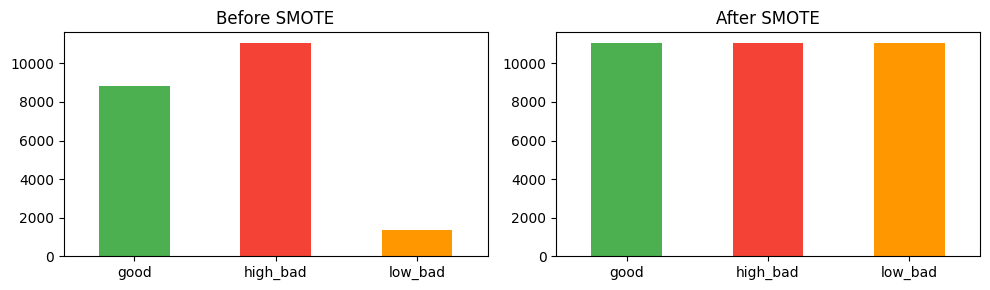

In [6]:
print('Before SMOTE:', dict(zip(*np.unique(y_train, return_counts=True))))

sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print('After SMOTE: ', dict(zip(*np.unique(y_train_sm, return_counts=True))))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
pd.Series(y_train).value_counts().sort_index().plot.bar(ax=axes[0], color=['#4CAF50', '#f44336', '#FF9800'])
axes[0].set_title('Before SMOTE')
axes[0].set_xticklabels(le_q.classes_, rotation=0)
pd.Series(y_train_sm).value_counts().sort_index().plot.bar(ax=axes[1], color=['#4CAF50', '#f44336', '#FF9800'])
axes[1].set_title('After SMOTE')
axes[1].set_xticklabels(le_q.classes_, rotation=0)
plt.tight_layout()
plt.show()

---
## 7. Task 1 — Global Quality Model (LightGBM)

### Why LightGBM over XGBoost?
- **Faster training** (histogram-based splits)
- **Better handling of categorical features** via `class_weight='balanced'`
- **Built-in early stopping** with `callbacks`
- **Isotonic calibration** for reliable probability estimates

In [7]:
lgb_params = {
    'objective':         'multiclass',
    'num_class':         3,
    'metric':            'multi_logloss',
    'n_estimators':      800,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
    'class_weight':      'balanced',
    'random_state':      RANDOM_STATE,
    'n_jobs':            -1,
    'verbose':           -1,
}

m1 = lgb.LGBMClassifier(**lgb_params)
m1.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

# Isotonic probability calibration
m1_cal = CalibratedClassifierCV(m1, cv='prefit', method='isotonic')
m1_cal.fit(X_val, y_val)

print('\n=== Validation Report (default threshold) ===')
y_val_pred = m1_cal.predict(X_val)
print(classification_report(y_val, y_val_pred, target_names=le_q.classes_))

print('\n=== Test Report (default threshold) ===')
y_test_pred = m1_cal.predict(X_test)
print(classification_report(y_test, y_test_pred, target_names=le_q.classes_))

[100]	valid_0's multi_logloss: 0.87012

=== Validation Report (default threshold) ===
              precision    recall  f1-score   support

        good       0.65      0.85      0.73      2329
    high_bad       0.74      0.57      0.64      1905
     low_bad       0.69      0.08      0.14       322

    accuracy                           0.68      4556
   macro avg       0.69      0.50      0.51      4556
weighted avg       0.69      0.68      0.65      4556


=== Test Report (default threshold) ===
              precision    recall  f1-score   support

        good       0.45      0.55      0.49      2148
    high_bad       0.29      0.37      0.33      1529
     low_bad       0.55      0.01      0.01       880

    accuracy                           0.38      4557
   macro avg       0.43      0.31      0.28      4557
weighted avg       0.42      0.38      0.35      4557



### Confusion Matrix & Feature Importance

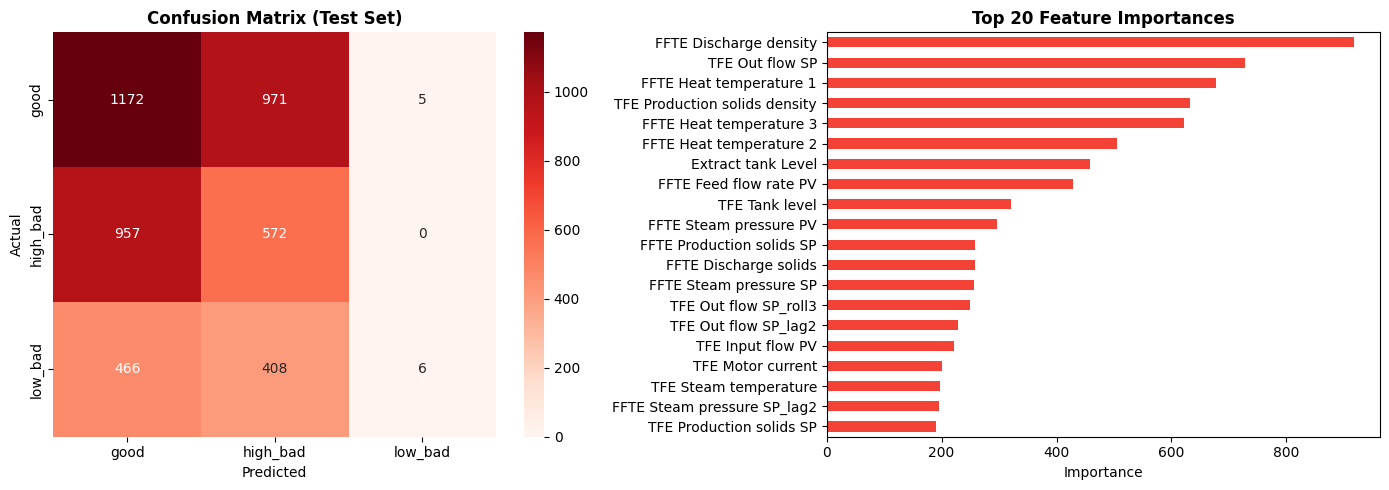

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (Test)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=le_q.classes_, yticklabels=le_q.classes_)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold')

# Feature Importance (top 20)
imp = pd.Series(m1.feature_importances_, index=USE_COLS)
imp.nlargest(20).sort_values().plot.barh(ax=axes[1], color='#f44336')
axes[1].set_title('Top 20 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

---
## 8. Threshold Tuning for `low_bad`

### Why?
`low_bad` is rare (~8% of data). Default argmax threshold misses many of these cases.  
We search for the optimal threshold that maximizes `low_bad` F1 without destroying overall accuracy.

In [9]:
low_bad_idx  = list(le_q.classes_).index('low_bad')
good_idx     = list(le_q.classes_).index('good')
high_bad_idx = list(le_q.classes_).index('high_bad')

val_proba = m1_cal.predict_proba(X_val)

best_thresh = 0.15
best_f1_lb  = 0.0
results = []

for thresh in np.arange(0.05, 0.50, 0.01):
    y_pred_t = []
    for p in val_proba:
        if p[low_bad_idx] >= thresh:
            y_pred_t.append(low_bad_idx)
        else:
            masked = p.copy()
            masked[low_bad_idx] = 0
            y_pred_t.append(np.argmax(masked))
    y_pred_t = np.array(y_pred_t)

    f1_lb  = f1_score(y_val, y_pred_t, labels=[low_bad_idx], average='macro', zero_division=0)
    f1_mac = f1_score(y_val, y_pred_t, average='macro', zero_division=0)
    acc    = accuracy_score(y_val, y_pred_t)
    results.append({'thresh': thresh, 'f1_lb': f1_lb, 'f1_mac': f1_mac, 'acc': acc})

    if f1_lb > best_f1_lb:
        best_f1_lb  = f1_lb
        best_thresh = thresh

df_thresh = pd.DataFrame(results)
print(f'Best threshold for low_bad: {best_thresh:.2f}  (val F1_lb={best_f1_lb:.3f})')
print(f'\nTop 10 thresholds by macro F1:')
print(df_thresh.sort_values('f1_mac', ascending=False).head(10).to_string(index=False))

Best threshold for low_bad: 0.14  (val F1_lb=0.196)

Top 10 thresholds by macro F1:
 thresh    f1_lb   f1_mac      acc
   0.14 0.196262 0.520716 0.668788
   0.16 0.192037 0.519262 0.668569
   0.15 0.192037 0.519262 0.668569
   0.17 0.192037 0.519262 0.668569
   0.26 0.192037 0.519262 0.668569
   0.25 0.192037 0.519262 0.668569
   0.24 0.192037 0.519262 0.668569
   0.23 0.192037 0.519262 0.668569
   0.22 0.192037 0.519262 0.668569
   0.21 0.192037 0.519262 0.668569


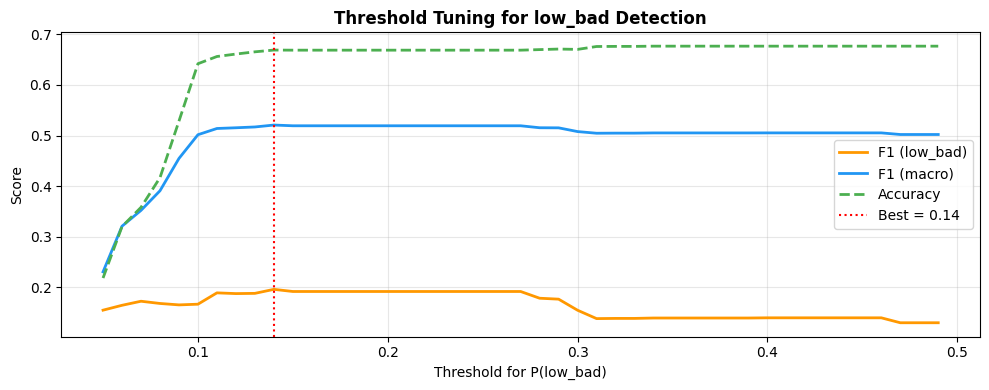


=== Test Report (tuned threshold) ===
              precision    recall  f1-score   support

        good       0.45      0.54      0.49      2148
    high_bad       0.29      0.37      0.33      1529
     low_bad       0.64      0.03      0.06       880

    accuracy                           0.39      4557
   macro avg       0.46      0.32      0.30      4557
weighted avg       0.44      0.39      0.36      4557



In [10]:
# Threshold tuning visualization
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_thresh['thresh'], df_thresh['f1_lb'], label='F1 (low_bad)', color='#FF9800', linewidth=2)
ax.plot(df_thresh['thresh'], df_thresh['f1_mac'], label='F1 (macro)', color='#2196F3', linewidth=2)
ax.plot(df_thresh['thresh'], df_thresh['acc'], label='Accuracy', color='#4CAF50', linewidth=2, linestyle='--')
ax.axvline(best_thresh, color='red', linestyle=':', label=f'Best = {best_thresh:.2f}')
ax.set_xlabel('Threshold for P(low_bad)')
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning for low_bad Detection', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Apply best threshold on test set
test_proba = m1_cal.predict_proba(X_test)
y_test_tuned = []
for p in test_proba:
    if p[low_bad_idx] >= best_thresh:
        y_test_tuned.append(low_bad_idx)
    else:
        masked = p.copy()
        masked[low_bad_idx] = 0
        y_test_tuned.append(np.argmax(masked))
y_test_tuned = np.array(y_test_tuned)

print('\n=== Test Report (tuned threshold) ===')
print(classification_report(y_test, y_test_tuned, target_names=le_q.classes_))

---
## 9. Per-Part (Yeast Type) Models

Train separate LightGBM models for each yeast type (BRD, BRN, FMX).  
Each part gets its own SMOTE, calibration, and optimized threshold.

In [11]:
per_part_models = {}
per_part_thresholds = {}

for part in prod['Part'].unique():
    print(f'\n{"="*60}')
    print(f'Training: {part}')
    print(f'{"="*60}')

    df_p_train = df_train[df_train['Part'] == part]
    df_p_val   = df_val[df_val['Part'] == part]
    df_p_test  = df_test[df_test['Part'] == part]

    if len(df_p_train) < 50 or df_p_train['label'].nunique() < 2:
        print(f'  Skipping: insufficient data ({len(df_p_train)} rows)')
        continue

    Xp_tr, yp_tr = df_p_train[USE_COLS].values, df_p_train['label'].values
    Xp_val, yp_val = df_p_val[USE_COLS].values, df_p_val['label'].values

    # SMOTE per part
    n_classes = len(np.unique(yp_tr))
    if n_classes >= 2 and min(np.bincount(yp_tr)) >= 5:
        sm_p = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, min(np.bincount(yp_tr)) - 1))
        try:
            Xp_tr, yp_tr = sm_p.fit_resample(Xp_tr, yp_tr)
            print(f'  SMOTE applied: {dict(zip(*np.unique(yp_tr, return_counts=True)))}')
        except Exception as e:
            print(f'  SMOTE failed: {e}')

    # LightGBM
    params_p = {**lgb_params, 'n_estimators': 500}
    mp = lgb.LGBMClassifier(**params_p)
    mp.fit(
        Xp_tr, yp_tr,
        eval_set=[(Xp_val, yp_val)] if len(Xp_val) > 0 else None,
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(200)],
    )

    # Calibrate
    if len(Xp_val) >= 10 and len(np.unique(yp_val)) >= 2:
        mp_cal = CalibratedClassifierCV(mp, cv='prefit', method='isotonic')
        mp_cal.fit(Xp_val, yp_val)
        print(f'  Calibrated with isotonic regression')
    else:
        mp_cal = mp

    per_part_models[part] = mp_cal

    # Threshold tuning per part
    if len(Xp_val) >= 20:
        vp_proba = mp_cal.predict_proba(Xp_val)
        best_t, best_f = 0.15, 0.0
        for t in np.arange(0.05, 0.45, 0.02):
            yp_pred_t = []
            for p_row in vp_proba:
                if p_row[low_bad_idx] >= t:
                    yp_pred_t.append(low_bad_idx)
                else:
                    masked = p_row.copy()
                    masked[low_bad_idx] = 0
                    yp_pred_t.append(np.argmax(masked))
            f = f1_score(yp_val, yp_pred_t, average='macro', zero_division=0)
            if f > best_f:
                best_f, best_t = f, t
        per_part_thresholds[part] = best_t
        print(f'  Best low_bad threshold: {best_t:.2f} (macro F1={best_f:.3f})')
    else:
        per_part_thresholds[part] = best_thresh
        print(f'  Using global threshold: {best_thresh:.2f}')

    # Evaluate on test
    if len(df_p_test) > 0:
        Xp_te, yp_te = df_p_test[USE_COLS].values, df_p_test['label'].values
        yp_pred = mp_cal.predict(Xp_te)
        print(f'  Test Accuracy: {accuracy_score(yp_te, yp_pred):.3f}')
        print(classification_report(yp_te, yp_pred, target_names=le_q.classes_, zero_division=0))

print(f'\nPer-Part Thresholds: {per_part_thresholds}')


Training: Yeast - FMX
  SMOTE applied: {np.int64(0): np.int64(4229), np.int64(1): np.int64(4229), np.int64(2): np.int64(4229)}
  Calibrated with isotonic regression
  Best low_bad threshold: 0.09 (macro F1=0.355)
  Test Accuracy: 0.406
              precision    recall  f1-score   support

        good       0.24      0.02      0.03      1066
    high_bad       0.41      0.95      0.57       996
     low_bad       0.00      0.00      0.00       309

    accuracy                           0.41      2371
   macro avg       0.22      0.32      0.20      2371
weighted avg       0.28      0.41      0.25      2371


Training: Yeast - BRN
  SMOTE applied: {np.int64(0): np.int64(2205), np.int64(1): np.int64(2205), np.int64(2): np.int64(2205)}
  Calibrated with isotonic regression
  Best low_bad threshold: 0.13 (macro F1=0.320)
  Test Accuracy: 0.343
              precision    recall  f1-score   support

        good       0.34      0.99      0.51       217
    high_bad       0.00      0.00   

---
## 10. Task 2 — Downtime Detection (LightGBM)

Binary classification: predict whether a production row is associated with downtime.
Merged using nearest-timestamp matching with 5-minute tolerance.

In [12]:
if downtime is not None:
    # Parse timestamps
    dt_col = [c for c in downtime.columns if 'time' in c.lower() or 'date' in c.lower()][0]
    downtime['Timestamp'] = pd.to_datetime(downtime[dt_col], dayfirst=True)
    downtime['downtime'] = 1
    prod['downtime'] = 0

    # Merge on nearest timestamp
    df_merged = pd.merge_asof(
        prod.sort_values('Set Time').rename(columns={'Set Time': 'Timestamp'}),
        downtime[['Timestamp', 'downtime']].sort_values('Timestamp'),
        on='Timestamp', direction='nearest', tolerance=pd.Timedelta('5min'),
        suffixes=('_prod', '_dt')
    )
    df_merged['downtime'] = df_merged['downtime_dt'].fillna(0).astype(int)
    print(f'Downtime distribution: {df_merged["downtime"].value_counts().to_dict()}')

    # Split
    n2 = len(df_merged)
    i2_val  = int(n2 * 0.70)
    i2_test = int(n2 * 0.85)

    X2_train = df_merged.iloc[:i2_val][USE_COLS].values
    y2_train = df_merged.iloc[:i2_val]['downtime'].values
    X2_val   = df_merged.iloc[i2_val:i2_test][USE_COLS].values
    y2_val   = df_merged.iloc[i2_val:i2_test]['downtime'].values
    X2_test  = df_merged.iloc[i2_test:][USE_COLS].values
    y2_test  = df_merged.iloc[i2_test:]['downtime'].values

    lgb_params2 = {
        'objective':         'binary',
        'metric':            'binary_logloss',
        'n_estimators':      500,
        'learning_rate':     0.05,
        'num_leaves':        31,
        'class_weight':      'balanced',
        'random_state':      RANDOM_STATE,
        'n_jobs':            -1,
        'verbose':           -1,
    }
    m2 = lgb.LGBMClassifier(**lgb_params2)
    m2.fit(
        X2_train, y2_train,
        eval_set=[(X2_val, y2_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(100)],
    )

    y2_pred = m2.predict(X2_test)
    print('\n=== Downtime Test Report ===')
    print(classification_report(y2_test, y2_pred))
    try:
        auc = roc_auc_score(y2_test, m2.predict_proba(X2_test)[:, 1])
        print(f'ROC-AUC: {auc:.4f}')
    except Exception:
        print('ROC-AUC: N/A (single class in test set)')
else:
    m2 = None
    print('No downtime data found — skipping Task 2')

Downtime distribution: {0: 30340, 1: 35}

=== Downtime Test Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4522
           1       0.00      0.00      0.00        35

    accuracy                           0.99      4557
   macro avg       0.50      0.50      0.50      4557
weighted avg       0.98      0.99      0.99      4557

ROC-AUC: 0.5000


---
## 11. Joint SP Optimization (Prescriptive)

Grid search over all 7 SPs simultaneously to find the configuration that  
maximizes P(good) while minimizing P(downtime), with a penalty for `low_bad`.

In [13]:
medians = prod[USE_COLS].median().to_dict()

def recommend_sp_joint(row_dict, part, model_q, model_dt, use_cols,
                       sp_cols, medians, le_q, low_bad_thresh=0.15, n_steps=5):
    """
    Grid search over all SPs simultaneously.
    Returns (best_sp_dict, p_good, p_downtime).
    """
    base = {c: medians.get(c, 0.0) for c in use_cols}
    base.update(row_dict)

    sp_ranges = {}
    for sp in sp_cols:
        med = medians.get(sp, base.get(sp, 0.0))
        lo, hi = med * 0.90, med * 1.10
        sp_ranges[sp] = np.linspace(lo, hi, n_steps)

    best_score = -1
    best_sp    = {sp: base.get(sp, medians.get(sp, 0)) for sp in sp_cols}
    best_pgood = 0.0
    best_pdt   = 1.0

    keys = list(sp_ranges.keys())
    for combo in itertools.product(*[sp_ranges[k] for k in keys]):
        row = base.copy()
        for k, v in zip(keys, combo):
            row[k] = v
        X = np.array([[row[c] for c in use_cols]])

        proba = model_q.predict_proba(X)[0]
        gi = list(le_q.classes_).index('good')
        li = list(le_q.classes_).index('low_bad')

        pgood = proba[gi] * (0.5 if proba[li] >= low_bad_thresh else 1.0)

        pdt = float(model_dt.predict_proba(X)[0][1]) if model_dt else 0.0
        score = pgood - 0.3 * pdt

        if score > best_score:
            best_score = score
            best_pgood = proba[gi]
            best_pdt   = pdt
            best_sp    = {k: v for k, v in zip(keys, combo)}

    return best_sp, best_pgood, best_pdt

# Demo: optimize for a median row
demo_sp, demo_pg, demo_pdt = recommend_sp_joint(
    row_dict=medians, part='Yeast - BRD',
    model_q=m1_cal, model_dt=m2,
    use_cols=USE_COLS, sp_cols=SP_COLS,
    medians=medians, le_q=le_q,
    low_bad_thresh=best_thresh, n_steps=3
)
print(f'Demo SP recommendation for Yeast-BRD:')
for k, v in demo_sp.items():
    print(f'  {k}: {v:.2f} (median: {medians.get(k, 0):.2f})')
print(f'  P(good)={demo_pg:.3f}, P(downtime)={demo_pdt:.3f}')

Demo SP recommendation for Yeast-BRD:
  FFTE Feed solids SP: 45.00 (median: 50.00)
  FFTE Production solids SP: 46.20 (median: 42.00)
  FFTE Steam pressure SP: 129.57 (median: 117.79)
  TFE Out flow SP: 2173.84 (median: 2415.38)
  TFE Production solids SP: 59.40 (median: 66.00)
  TFE Vacuum pressure SP: -62.85 (median: -69.83)
  TFE Steam pressure SP: 108.00 (median: 120.00)
  P(good)=0.750, P(downtime)=0.000


---
## 12. Ordinal-Aware Evaluation

Quality is ordinal: `good > low_bad > high_bad`.  
Misclassifying `good` as `high_bad` (2 steps) is worse than `good` as `low_bad` (1 step).

In [14]:
# Ordinal mapping
ord_map = {le_q.transform([c])[0]: ORDINAL[c] for c in le_q.classes_}

def mean_absolute_ordinal_error(y_true, y_pred, ord_map):
    """Average absolute ordinal distance."""
    errors = [abs(ord_map[t] - ord_map[p]) for t, p in zip(y_true, y_pred)]
    return np.mean(errors)

# Evaluate
mae_default = mean_absolute_ordinal_error(y_test, y_test_pred, ord_map)
mae_tuned   = mean_absolute_ordinal_error(y_test, y_test_tuned, ord_map)

print(f'Mean Absolute Ordinal Error (default threshold): {mae_default:.4f}')
print(f'Mean Absolute Ordinal Error (tuned threshold):   {mae_tuned:.4f}')
print(f'\nLower is better. A score of 0 means perfect ordinal prediction.')

# Comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', 'Ordinal MAE', 'low_bad F1'],
    'Default Threshold': [
        accuracy_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred, average='macro'),
        mae_default,
        f1_score(y_test, y_test_pred, labels=[low_bad_idx], average='macro', zero_division=0),
    ],
    'Tuned Threshold': [
        accuracy_score(y_test, y_test_tuned),
        f1_score(y_test, y_test_tuned, average='macro'),
        mae_tuned,
        f1_score(y_test, y_test_tuned, labels=[low_bad_idx], average='macro', zero_division=0),
    ]
})
print(comparison.to_string(index=False))

Mean Absolute Ordinal Error (default threshold): 1.0391
Mean Absolute Ordinal Error (tuned threshold):   1.0364

Lower is better. A score of 0 means perfect ordinal prediction.
     Metric  Default Threshold  Tuned Threshold
   Accuracy           0.384025         0.386658
   Macro F1           0.278802         0.295448
Ordinal MAE           1.039061         1.036427
 low_bad F1           0.013468         0.064725


---
## 13. Save Artifacts

Save all models and metadata for deployment. Upload the 4 `.joblib` files to `models/` directory.

In [15]:
artifacts = {
    'le_q':                le_q,
    'le_part':             le_part,
    'use_cols':            USE_COLS,
    'sp_cols':             SP_COLS,
    'medians':             medians,
    'low_bad_threshold':   best_thresh,
    'per_part_thresholds': per_part_thresholds,
    'part_target_enc':     part_target_enc,
}

os.makedirs(OUTPUT_DIR, exist_ok=True)
joblib.dump(m1_cal,          os.path.join(OUTPUT_DIR, 'vegemite_task1.joblib'))
joblib.dump(per_part_models, os.path.join(OUTPUT_DIR, 'vegemite_task1_per_part.joblib'))
if m2 is not None:
    joblib.dump(m2,          os.path.join(OUTPUT_DIR, 'vegemite_task2.joblib'))
joblib.dump(artifacts,       os.path.join(OUTPUT_DIR, 'vegemite_artifacts.joblib'))

print('Saved artifacts:')
for f in ['vegemite_task1.joblib', 'vegemite_task1_per_part.joblib',
           'vegemite_task2.joblib', 'vegemite_artifacts.joblib']:
    p = os.path.join(OUTPUT_DIR, f)
    if os.path.exists(p):
        print(f'  {f}: {os.path.getsize(p) / 1024:.1f} KB')

print(f'\nPer-Part Thresholds: {per_part_thresholds}')
print(f'Global low_bad Threshold: {best_thresh:.2f}')
print(f'Part Target Encoding: {part_target_enc}')
print('\nDone! Upload the .joblib files to models/ directory.')

Saved artifacts:
  vegemite_task1.joblib: 1235.2 KB
  vegemite_task1_per_part.joblib: 2051.0 KB
  vegemite_task2.joblib: 7.5 KB
  vegemite_artifacts.joblib: 5.0 KB

Per-Part Thresholds: {'Yeast - FMX': np.float64(0.09000000000000001), 'Yeast - BRN': np.float64(0.13), 'Yeast - BRD': np.float64(0.11000000000000001)}
Global low_bad Threshold: 0.14
Part Target Encoding: {'Yeast - BRD': 1.0464071856287425, 'Yeast - BRN': 1.1300157977883096, 'Yeast - FMX': 0.7705452303355941}

Done! Upload the .joblib files to models/ directory.
